# LangChain e LangGraph

Na Unidade I cada peça do agente foi escrita à mão: modelo, mensagens, ferramentas, laço e memória. A Unidade II usa duas bibliotecas que trazem essas peças prontas. LangChain dá o modelo, as mensagens e as ferramentas com uma interface só para qualquer provedor. LangGraph dá o laço, escrito como um grafo de estado.

A primeira parte do notebook percorre o LangChain no essencial, sempre apontando para o que a peça correspondia na Unidade I. A segunda parte constrói grafos do mais simples ao agente com ferramentas e memória.

In [1]:
# No Google Colab, descomente e rode uma vez.
# !pip install -q langchain langchain-openai langgraph

from typing import Annotated, Literal

from IPython.display import Image
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain.tools import tool
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages

## LangChain

### Chamando o modelo

A string escolhe o provedor e o modelo. Cada provedor tem um pacote de integração, e todos devolvem um objeto com a mesma interface, que é o que `LLM` e `LLMAPI` faziam na Unidade I.

In [2]:
model = init_chat_model("openai:gpt-4.1-mini", temperature=0.0)

# As linhas abaixo trocam o provedor sem mudar o resto do notebook.
# model = init_chat_model("groq:openai/gpt-oss-120b", temperature=0.0)
# model = init_chat_model("ollama:qwen2.5:1.5b", temperature=0.0)

response = model.invoke("Quanto é 2 + 2?")
response

AIMessage(content='2 + 2 é igual a 4.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 15, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_bbc2089160', 'id': 'chatcmpl-EP82bMTr1Cmw0lleMj92nDpSuiQoM', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0afeb-1d86-78e2-b1e9-9367ff2a1fe3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 10, 'total_tokens': 25, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

O `invoke` devolve uma `AIMessage` em vez de texto. O texto está em `content`, e o consumo da chamada em `usage_metadata`.

In [3]:
print(response.content)
print(response.usage_metadata)

2 + 2 é igual a 4.
{'input_tokens': 15, 'output_tokens': 10, 'total_tokens': 25, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [4]:
for chunk in model.stream("Conte de um a cinco, com os números por extenso."):
    print(chunk.content, end="|")

|Um|,| dois|,| três|,| quatro|,| cinco|.||||

### Mensagens

O dicionário `{"role": ..., "content": ...}` continua aceito, e o LangChain acrescenta uma classe por papel. A conversa é uma lista dessas mensagens, como na Unidade I, e a resposta do modelo entra na lista como o próprio objeto devolvido.

In [5]:
messages = [
    SystemMessage("Responda em uma frase."),
    HumanMessage("O que é um agente?"),
]

response = model.invoke(messages)
messages.append(response)
messages.append(HumanMessage("E o que ele não é?"))

print(model.invoke(messages).content)

Um agente não é simplesmente um programa passivo ou estático, pois ele age de forma autônoma e reativa no ambiente.


### Templates de mensagens

Na aula de prompt o contexto era montado com f-strings. O `ChatPromptTemplate` faz a mesma montagem sobre uma lista de mensagens, com as variáveis entre chaves. O `MessagesPlaceholder` reserva o lugar de uma lista inteira de mensagens, que é onde entra o histórico.

In [6]:
prompt = ChatPromptTemplate.from_messages([
    ("system", "Você é um assistente da área de {area}. Responda em uma frase."),
    MessagesPlaceholder("history"),
    ("human", "{question}"),
])

filled = prompt.invoke({
    "area": "astronomia",
    "history": [HumanMessage("Oi"), AIMessage("Olá, como posso ajudar?")],
    "question": "Por que a Lua tem fases?",
})
filled.messages

[SystemMessage(content='Você é um assistente da área de astronomia. Responda em uma frase.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Oi', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Olá, como posso ajudar?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Por que a Lua tem fases?', additional_kwargs={}, response_metadata={})]

### Runnables

Modelo, template e o resto das peças do LangChain são runnables: todos têm `invoke`, `stream` e `batch`. O operador `|` liga um runnable ao seguinte, passando a saída de um como entrada do próximo, e o resultado é outro runnable.

In [7]:
chain = prompt | model | StrOutputParser()

print(chain.invoke({"area": "astronomia", "history": [], "question": "Por que a Lua tem fases?"}))

A Lua tem fases porque sua posição relativa em relação à Terra e ao Sol muda, fazendo com que diferentes partes de sua superfície iluminada sejam visíveis da Terra.


In [8]:
questions = ["Qual é a capital da França?", "Qual é a capital do Japão?"]

for answer in model.batch(questions):
    print(answer.content)

A capital da França é Paris.
A capital do Japão é Tóquio.


### Saída estruturada

O `with_structured_output` recebe um esquema Pydantic e devolve um runnable que responde com o objeto validado, como o `generate_structured` da Unidade I.

In [9]:
class Event(BaseModel):
    name: str
    city: str
    date: str = Field(description="Data no formato AAAA-MM-DD")


structured_model = model.with_structured_output(Event)
structured_model.invoke("A Campus Party acontece em São Paulo no dia 12 de julho de 2026.")

Event(name='Campus Party', city='São Paulo', date='2026-07-12')

### Ferramentas

O decorador `tool` lê a assinatura e a docstring, como o da Unidade I. A diferença é que ele devolve um objeto em vez da função, e a execução passa por `invoke`.

In [10]:
@tool
def calculate(expression: str) -> str:
    """Avalia uma expressão aritmética, como 12 * (3 + 4)."""
    return str(eval(expression, {"__builtins__": {}}, {}))


print(calculate.name)
print(calculate.description)
print(calculate.args)
print(calculate.invoke({"expression": "4871 * 3926"}))

calculate
Avalia uma expressão aritmética, como 12 * (3 + 4).
{'expression': {'title': 'Expression', 'type': 'string'}}
19123546


O `bind_tools` liga as ferramentas ao modelo. A chamada volta em `tool_calls`, já estruturada e com um `id`, e o `parse_tool_call` da aula de ferramentas deixa de existir.

In [11]:
model_with_tools = model.bind_tools([calculate])

question = "Quanto é 4871 vezes 3926?"
response = model_with_tools.invoke(question)
response.tool_calls

[{'name': 'calculate',
  'args': {'expression': '4871 * 3926'},
  'id': 'call_PTs9Z9g0pW0HjSrM9G5i9kJE',
  'type': 'tool_call'}]

Passar a chamada inteira para `invoke` executa a ferramenta e devolve uma `ToolMessage` com o `tool_call_id` preenchido. O ciclo fecha como na Unidade I: pergunta, chamada, observação, resposta.

In [12]:
observation = calculate.invoke(response.tool_calls[0])
print(observation)

print(model_with_tools.invoke([HumanMessage(question), response, observation]).content)

content='19123546' name='calculate' tool_call_id='call_PTs9Z9g0pW0HjSrM9G5i9kJE'


4871 vezes 3926 é igual a 19.123.546. Posso ajudar com mais alguma coisa?


### Exercício 1

Monte um `ChatPromptTemplate` com a mensagem de sistema do domínio da sua equipe e uma variável para a pergunta, e ligue-o ao modelo com `|`. Escreva uma ferramenta do seu domínio com `@tool`, ligue-a ao modelo com `bind_tools` e feche um ciclo de chamada e observação à mão. Mostre a chamada que o modelo pediu e a resposta final.

In [13]:
# Seu código aqui

## LangGraph

O LangChain trouxe as peças e não trouxe o laço. O LangGraph escreve o laço como um grafo: um estado compartilhado, nós que são funções sobre o estado e arestas que dizem qual nó vem depois.

### Estado, nós e arestas

O estado é um `TypedDict`. Cada nó recebe o estado inteiro e devolve um dicionário só com as chaves que quer atualizar. O grafo abaixo não usa modelo nenhum, para que o mecanismo apareça sozinho.

In [14]:
class State(TypedDict):
    text: str
    words: int


def clean(state: State) -> dict:
    """Remove espaços extras do texto."""
    return {"text": " ".join(state["text"].split())}


def count(state: State) -> dict:
    """Conta as palavras do texto."""
    return {"words": len(state["text"].split())}

O grafo é montado com o estado, recebe os nós pelo nome e as arestas entre eles. `START` e `END` são os dois nós que todo grafo já tem. Compilar transforma a descrição em um runnable.

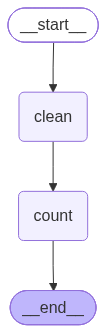

In [15]:
builder = StateGraph(State)
builder.add_node("clean", clean)
builder.add_node("count", count)
builder.add_edge(START, "clean")
builder.add_edge("clean", "count")
builder.add_edge("count", END)

graph = builder.compile()
Image(graph.get_graph().draw_mermaid_png())

In [16]:
graph.invoke({"text": "  inteligência   artificial  é   legal "})

{'text': 'inteligência artificial é legal', 'words': 4}

A entrada é um estado parcial e a saída é o estado final. O `clean` substituiu `text`, e o `count` leu o texto já limpo e escreveu `words`. Cada nó só mexe no que devolve.

### Um nó com modelo

Um nó que chama o modelo é uma função como as outras. O estado agora carrega a conversa, e o nó devolve a resposta.

In [17]:
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]


def respond(state: ChatState) -> dict:
    """Chama o modelo com a conversa inteira."""
    return {"messages": [model.invoke(state["messages"])]}


builder = StateGraph(ChatState)
builder.add_node("respond", respond)
builder.add_edge(START, "respond")
builder.add_edge("respond", END)

chat_graph = builder.compile()
result = chat_graph.invoke({"messages": [HumanMessage("O que é um agente? Responda em uma frase.")]})
result["messages"]

[HumanMessage(content='O que é um agente? Responda em uma frase.', additional_kwargs={}, response_metadata={}, id='736dbeba-beeb-4fc9-ba6a-21a2c662e33e'),
 AIMessage(content='Um agente é uma entidade que percebe o ambiente por meio de sensores e atua sobre ele por meio de atuadores para alcançar objetivos.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 20, 'total_tokens': 46, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_d6013e0d3c', 'id': 'chatcmpl-EP82jIDtZbb2ozznayB8Y7o4aiXRp', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0afeb-4037-7241-9883-ea4150c28b56-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_token

A conversa tem duas mensagens, e não uma. Por padrão a atualização de um nó substitui o valor, e a lista de mensagens seria apagada a cada resposta. O `Annotated` com `add_messages` troca a substituição por acréscimo, e isso se chama reducer.

### Arestas condicionais

Uma aresta condicional é uma função que lê o estado e devolve o nome do próximo nó. O grafo abaixo classifica o pedido e manda cada tipo para um nó diferente.

In [18]:
class Route(BaseModel):
    kind: Literal["conta", "conversa"]
    expression: str = Field(default="", description="A expressão aritmética, se o pedido for uma conta")


class RouterState(TypedDict):
    question: str
    kind: str
    expression: str
    answer: str


def classify(state: RouterState) -> dict:
    """Decide se o pedido é uma conta ou uma conversa."""
    route = model.with_structured_output(Route).invoke(state["question"])
    return {"kind": route.kind, "expression": route.expression}


def compute(state: RouterState) -> dict:
    """Resolve a conta com a ferramenta."""
    return {"answer": calculate.invoke({"expression": state["expression"]})}


def chat(state: RouterState) -> dict:
    """Responde com o modelo."""
    return {"answer": model.invoke(state["question"]).content}


def route(state: RouterState) -> Literal["compute", "chat"]:
    """Escolhe o próximo nó pelo tipo do pedido."""
    return "compute" if state["kind"] == "conta" else "chat"

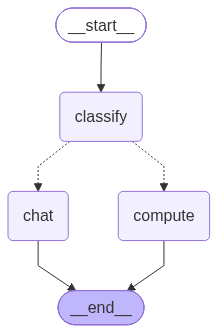

In [19]:
builder = StateGraph(RouterState)
builder.add_node("classify", classify)
builder.add_node("compute", compute)
builder.add_node("chat", chat)
builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route, ["compute", "chat"])
builder.add_edge("compute", END)
builder.add_edge("chat", END)

router = builder.compile()
Image(router.get_graph().draw_mermaid_png())

In [20]:
for question in ["Quanto é 4871 vezes 3926?", "Quem escreveu Dom Casmurro?"]:
    result = router.invoke({"question": question})
    print(result["kind"], ":", result["answer"])

conta : 19123546


conversa : "Dom Casmurro" foi escrito por Machado de Assis.


As linhas tracejadas do desenho são as arestas condicionais. A lista passada em `add_conditional_edges` diz quais destinos a função pode devolver, e serve para o desenho e para a validação do grafo.

### Workflow com ciclo

Uma aresta pode voltar para um nó anterior, e aí o grafo tem um laço. O workflow abaixo é a reflexão da aula de planejamento: um nó escreve, outro revisa, e o texto volta para a escrita enquanto houver problema.

O revisor é código, e não modelo, como o `pytest` da aula de harness. Ele conta caracteres sem errar e não custa token. O feedback vazio significa aprovado.

In [21]:
class WriterState(TypedDict):
    task: str
    draft: str
    feedback: str
    attempts: int


def write(state: WriterState) -> dict:
    """Escreve o texto, incorporando o feedback se houver."""
    request = state["task"]
    if state.get("feedback"):
        request += f"\n\nRascunho anterior:\n{state['draft']}\n\nProblemas encontrados: {state['feedback']}"
    messages = [SystemMessage("Responda só com o texto pedido, sem comentários."), HumanMessage(request)]
    return {"draft": model.invoke(messages).content, "attempts": state.get("attempts", 0) + 1}


def review(state: WriterState) -> dict:
    """Verifica as restrições da tarefa e descreve o que falhou."""
    draft = state["draft"]
    problems = []
    if not 50 <= len(draft) <= 60:
        problems.append(f"tem {len(draft)} caracteres em vez de 50 a 60")
    if "mar" in draft.lower():
        problems.append("usa a palavra mar")
    return {"feedback": "; ".join(problems)}


def should_rewrite(state: WriterState) -> Literal["write", END]:
    """Volta para a escrita até não haver problema ou esgotar as tentativas."""
    if not state["feedback"] or state["attempts"] >= 3:
        return END
    return "write"

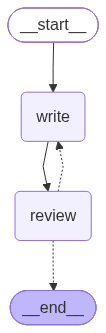

In [22]:
builder = StateGraph(WriterState)
builder.add_node("write", write)
builder.add_node("review", review)
builder.add_edge(START, "write")
builder.add_edge("write", "review")
builder.add_conditional_edges("review", should_rewrite, ["write", END])

writer = builder.compile()
Image(writer.get_graph().draw_mermaid_png())

O `stream` com `stream_mode="updates"` devolve, a cada passo, o que aquele nó mudou no estado. É o traço do workflow sem código a mais.

In [23]:
TASK = "Escreva uma frase sobre o mar com 50 a 60 caracteres, contando os espaços, sem usar a palavra mar."

for step in writer.stream({"task": TASK}, stream_mode="updates"):
    node, update = next(iter(step.items()))
    print(node, ":", update)

write : {'draft': 'Ondas dançam sob o céu, trazendo paz e liberdade.', 'attempts': 1}
review : {'feedback': 'tem 49 caracteres em vez de 50 a 60'}


write : {'draft': 'Ondas dançam sob o céu azul, trazendo paz e liberdade.', 'attempts': 2}
review : {'feedback': ''}


O modelo errou a contagem na primeira tentativa, o revisor devolveu o número exato e a segunda passou. O `attempts` é o `max_steps` deste laço: sem ele, um texto que nunca satisfaz o revisor roda para sempre.

### Exercício 2

Monte um workflow para o domínio da sua equipe com pelo menos três nós e uma aresta condicional. Uma opção é o esquema classificar e despachar; outra é o esquema escrever e revisar. Rode com `stream_mode="updates"` para dois pedidos diferentes e mostre o caminho que cada um percorreu.

In [24]:
# Seu código aqui

### Agente

O agente é o workflow mais simples com ciclo: um nó chama o modelo com ferramentas ligadas, outro executa as chamadas, e a aresta condicional volta para o modelo enquanto ele pedir ferramenta. É o `Agent.run` da Unidade I desenhado.

In [25]:
tools = [calculate]
tools_by_name = {fn.name: fn for fn in tools}
model_with_tools = model.bind_tools(tools)

SYSTEM = "Você não faz contas de cabeça: toda conta é feita pela ferramenta."


def call_model(state: ChatState) -> dict:
    """Chama o modelo com ferramentas ligadas."""
    return {"messages": [model_with_tools.invoke([SystemMessage(SYSTEM)] + state["messages"])]}


def run_tools(state: ChatState) -> dict:
    """Executa as chamadas da última mensagem e devolve as observações."""
    calls = state["messages"][-1].tool_calls
    return {"messages": [tools_by_name[call["name"]].invoke(call) for call in calls]}


def should_continue(state: ChatState) -> Literal["run_tools", END]:
    """Vai para as ferramentas se o modelo pediu alguma, senão termina."""
    if state["messages"][-1].tool_calls:
        return "run_tools"
    return END

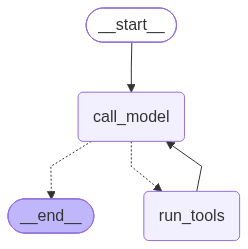

In [26]:
builder = StateGraph(ChatState)
builder.add_node("call_model", call_model)
builder.add_node("run_tools", run_tools)
builder.add_edge(START, "call_model")
builder.add_conditional_edges("call_model", should_continue, ["run_tools", END])
builder.add_edge("run_tools", "call_model")

agent = builder.compile()
Image(agent.get_graph().draw_mermaid_png())

In [27]:
result = agent.invoke({"messages": [HumanMessage("Quanto é 4871 vezes 3926, e quanto é a metade disso?")]})

for message in result["messages"]:
    print(message.type, ":", message.tool_calls if getattr(message, "tool_calls", None) else message.content)

human : Quanto é 4871 vezes 3926, e quanto é a metade disso?
ai : [{'name': 'calculate', 'args': {'expression': '4871 * 3926'}, 'id': 'call_njKbWltgyd41boc7rQf38XEx', 'type': 'tool_call'}, {'name': 'calculate', 'args': {'expression': '(4871 * 3926) / 2'}, 'id': 'call_v13bWaKy2vjKK1ybicq9Y7aO', 'type': 'tool_call'}]
tool : 19123546
tool : 9561773.0
ai : 4871 vezes 3926 é 19.123.546, e a metade disso é 9.561.773.


O `max_steps` da Unidade I não existe no grafo. A proteção contra laço infinito é o `recursion_limit` da configuração, que conta passos de qualquer nó e vale 25 por padrão.

### Memória

Na aula de memória, sessão era um histórico por identificador. No grafo isso é um checkpointer: o estado é salvo depois de cada nó, indexado pelo `thread_id` da configuração. A mesma thread continua a conversa, e outra thread começa do zero.

In [28]:
agent = builder.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "sessao-1"}}

result = agent.invoke({"messages": [HumanMessage("Meu nome é Silvan. Quanto é 12 vezes 12?")]}, config)
print(result["messages"][-1].content)

result = agent.invoke({"messages": [HumanMessage("Qual é o meu nome?")]}, config)
print(result["messages"][-1].content)

Olá, Silvan! 12 vezes 12 é 144. Posso ajudar em mais alguma coisa?


Seu nome é Silvan. Posso ajudar em mais alguma coisa?


In [29]:
result = agent.invoke({"messages": [HumanMessage("Qual é o meu nome?")]}, {"configurable": {"thread_id": "sessao-2"}})
print(result["messages"][-1].content)

Eu não sei qual é o seu nome, pois você ainda não me disse. Qual é o seu nome?


O `InMemorySaver` some com o kernel. Trocá-lo por um checkpointer em SQLite ou Postgres é uma linha, e o grafo passa a retomar do último nó salvo depois de uma queda.

### O agente pronto

O `create_agent` do LangChain monta o grafo que acabou de ser construído. Ele recebe modelo, ferramentas, mensagem de sistema e checkpointer, e o desenho mostra os mesmos dois nós.

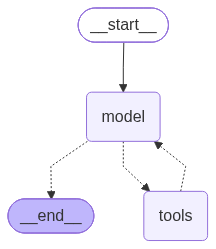

In [30]:
prebuilt = create_agent(model, tools=tools, system_prompt=SYSTEM, checkpointer=InMemorySaver())

Image(prebuilt.get_graph().draw_mermaid_png())

In [31]:
result = prebuilt.invoke({"messages": [HumanMessage("Quanto é 4871 vezes 3926?")]}, config)
print(result["messages"][-1].content)

4871 vezes 3926 é igual a 19.123.546. Posso ajudar em mais alguma coisa?


### Exercício 3

Monte o agente do domínio da sua equipe com pelo menos duas ferramentas, com o grafo escrito à mão e com checkpointer. Rode um pedido que exija as duas ferramentas e depois uma pergunta que dependa do pedido anterior, na mesma thread. Mostre a conversa completa ao final.

In [32]:
# Seu código aqui